**Chapter 13 – Processing Sequences Using RNNs and CNNs**

_This notebook contains all the sample code and solutions to the exercises in chapter 13._

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/ageron/handson-mlp/blob/main/13_processing_sequences_using_rnns_and_cnns.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/ageron/handson-mlp/blob/main/13_processing_sequences_using_rnns_and_cnns.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

# Setup

This project requires Python 3.10 or above:

In [74]:
import sys

assert sys.version_info >= (3, 10)

Are we using Colab or Kaggle?

In [75]:
IS_COLAB = "google.colab" in sys.modules
IS_KAGGLE = "kaggle_secrets" in sys.modules

If using Colab, the TorchMetrics library is not pre-installed so we must install it manually:

In [76]:
if IS_COLAB:
    %pip install -q torchmetrics

In [77]:
%pip install -q torchmetrics

Note: you may need to restart the kernel to use updated packages.


We also need PyTorch ≥ 2.6.0:

In [78]:
from packaging.version import Version
import torch

assert Version(torch.__version__) >= Version("2.6.0")

This chapter can be very slow without a hardware accelerator, so if we can find one, let's use it:

In [79]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

device

'mps'

Let's issue a warning if there's no hardware accelerator available:

In [80]:
if device == "cpu":
    print("Neural nets can be very slow without a hardware accelerator.")
    if IS_COLAB:
        print("Go to Runtime > Change runtime and select a GPU hardware "
              "accelerator.")
    if IS_KAGGLE:
        print("Go to Settings > Accelerator and select GPU.")

As we did in earlier chapters, let's define the default font sizes to make the figures prettier:

In [81]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

# Training RNNs

## Forecasting a Time Series

Let's download the ridership data from the ageron/data project. It originally comes from Chicago's Transit Authority, and was downloaded from the [Chicago's Data Portal](https://homl.info/ridership).

In [82]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

def download_and_extract_ridership_data():
    tarball_path = Path("datasets/ridership.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/ridership.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets", filter="data")

download_and_extract_ridership_data()

Now let's clean up the data a bit:

In [83]:
import pandas as pd
from pathlib import Path

path = Path("datasets/ridership/CTA_-_Ridership_-_Daily_Boarding_Totals.csv")
df = pd.read_csv(path, parse_dates=["service_date"])
df.columns = ["date", "day_type", "bus", "rail", "total"]  # shorter names
df = df.sort_values("date").set_index("date")
df = df.drop("total", axis=1)  # no need for total, it's just bus + rail
df = df.drop_duplicates()  # remove duplicated months (2011-10 and 2014-07)

In [84]:
df.head()

,day_type,bus,rail
date,,,
2001-01-01,U,297192,126455
2001-01-02,W,780827,501952
2001-01-03,W,824923,536432
2001-01-04,W,870021,550011
2001-01-05,W,890426,557917


Let's look at the first few months of 2019 (note that Pandas treats the range boundaries as inclusive):

In [85]:
len(df)

7639

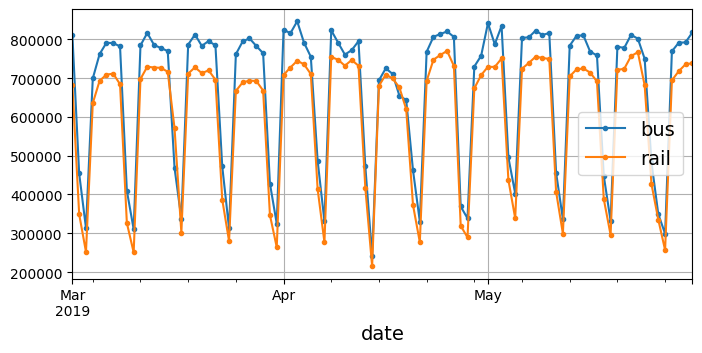

In [86]:
import matplotlib.pyplot as plt

df["2019-03":"2019-05"].plot(grid=True, marker=".", figsize=(8, 3.5))
plt.show()

In [87]:
df.head()

,day_type,bus,rail
date,,,
2001-01-01,U,297192,126455
2001-01-02,W,780827,501952
2001-01-03,W,824923,536432
2001-01-04,W,870021,550011
2001-01-05,W,890426,557917


In [88]:
df.shift(7).head()

,day_type,bus,rail
date,,,
2001-01-01,None,NaN,NaN
2001-01-02,None,NaN,NaN
2001-01-03,None,NaN,NaN
2001-01-04,None,NaN,NaN
2001-01-05,None,NaN,NaN


In [89]:
diff_7.head()

,bus,rail
date,,
2019-03-01,13927.0,-20019.0
2019-03-02,47280.0,21213.0
2019-03-03,25171.0,11672.0
2019-03-04,-63771.0,-45491.0
2019-03-05,-11268.0,-6517.0


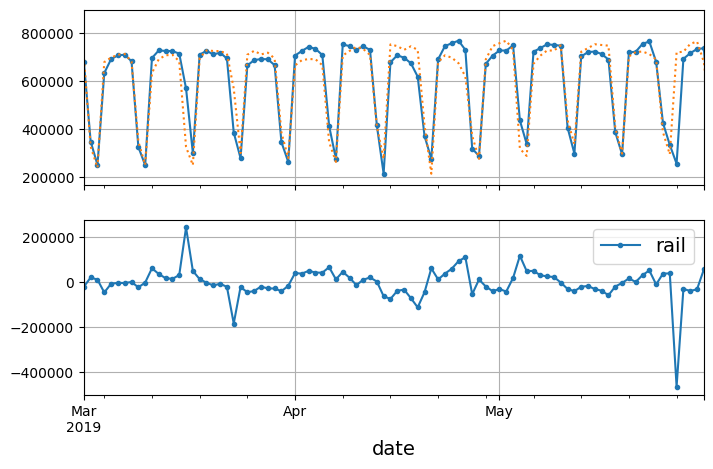

In [90]:
diff_7 = df[["rail"]].diff(7)["2019-03":"2019-05"]

fig, axs = plt.subplots(2, 1, sharex=True, figsize=(8, 5))
df["rail"].plot(ax=axs[0], legend=False, marker=".")  # original time series
df["rail"].shift(7).plot(ax=axs[0], grid=True, legend=False, linestyle=":")  # lagged
diff_7.plot(ax=axs[1], grid=True, marker=".")  # 7-day difference time series
axs[0].set_ylim([170_000, 900_000])  # extra code – beautifies the plot

plt.show()

In [91]:
diff_7.head()

,rail
date,
2019-03-01,-20019.0
2019-03-02,21213.0
2019-03-03,11672.0
2019-03-04,-45491.0
2019-03-05,-6517.0


In [92]:
diff_7.tail()

,rail
date,
2019-05-27,-464640.0
2019-05-28,-29490.0
2019-05-29,-38958.0
2019-05-30,-31209.0
2019-05-31,56879.0


In [93]:
diff_7['rail'].abs().mean()

np.float64(42143.27173913043)

In [94]:
diff_7.describe()

,rail
count,92.000000
mean,-1886.423913
std,71235.318601
min,-464640.000000
25%,-30066.500000
50%,-1596.000000
75%,33165.750000
max,244017.000000


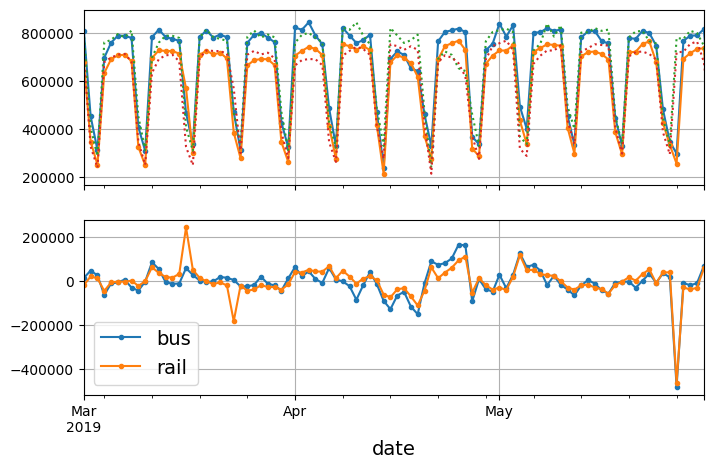

In [95]:
diff_7 = df[["bus", "rail"]].diff(7)["2019-03":"2019-05"]
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(8, 5))
df.plot(ax=axs[0], legend=False, marker=".")  # original time series
df.shift(7).plot(ax=axs[0], grid=True, legend=False, linestyle=":")  # lagged
diff_7.plot(ax=axs[1], grid=True, marker=".")  # 7-day difference time series
axs[0].set_ylim([170_000, 900_000])  # extra code – beautifies the plot

plt.show()

In [96]:
list(df.loc["2019-05-25":"2019-05-27"]["day_type"])

['A', 'U', 'U']

Mean absolute error (MAE), also called mean absolute deviation (MAD):

In [97]:
diff_7.abs().mean()

bus     43915.608696
rail    42143.271739
dtype: float64

Mean absolute percentage error (MAPE):

In [98]:
targets = df[["bus", "rail"]]["2019-03":"2019-05"]
(diff_7 / targets).abs().mean()

bus     0.082938
rail    0.089948
dtype: float64

Now let's look at the yearly seasonality and the long-term trends:

In [99]:
period

slice('2001', '2019', None)

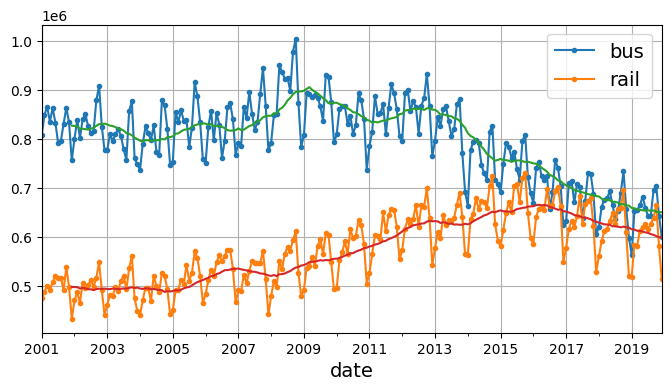

In [100]:
period = slice("2001", "2019")
df_monthly = df.select_dtypes(include="number").resample('ME').mean()
rolling_average_12_months = df_monthly.loc[period].rolling(window=12).mean()

fig, ax = plt.subplots(figsize=(8, 4))
df_monthly[period].plot(ax=ax, marker=".")
rolling_average_12_months.plot(ax=ax, grid=True, legend=False)
plt.show()

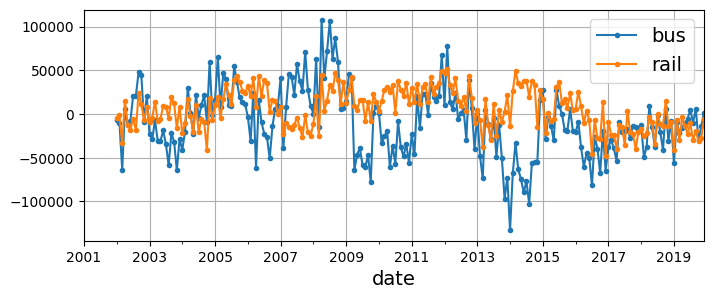

In [101]:
df_monthly.diff(12)[period].plot(grid=True, marker=".", figsize=(8, 3))
plt.show()

## The ARMA Model Family

If running on Colab or Kaggle, install the statsmodels library:

In [102]:
if IS_COLAB:
    %pip install -q -U statsmodels

In [103]:
from statsmodels.tsa.arima.model import ARIMA

origin, today = "2019-01-01", "2019-05-31"
rail_series = df.loc[origin:today]["rail"].asfreq("D")
model = ARIMA(rail_series,
              order=(1, 0, 0),
              seasonal_order=(0, 1, 1, 7))
model = model.fit()
y_pred = model.forecast()  # returns 427,758.6

ModuleNotFoundError: No module named 'statsmodels'

In [ ]:
y_pred.iloc[0]  # ARIMA forecast

In [ ]:
df["rail"].loc["2019-06-01"]  # target value

In [ ]:
df["rail"].loc["2019-05-25"]  # naive forecast (value from one week earlier)

In [ ]:
origin, start_date, end_date = "2019-01-01", "2019-03-01", "2019-05-31"
time_period = pd.date_range(start_date, end_date)
rail_series = df.loc[origin:end_date]["rail"].asfreq("D")
y_preds = []
for today in time_period.shift(-1):
    model = ARIMA(rail_series[origin:today],  # train on data up to "today"
                  order=(1, 0, 0),
                  seasonal_order=(0, 1, 1, 7))
    model = model.fit()  # note that we retrain the model every day!
    y_pred = model.forecast().iloc[0]
    y_preds.append(y_pred)

y_preds = pd.Series(y_preds, index=time_period)
mae = (y_preds - rail_series[time_period]).abs().mean()  # returns 32,040.7

In [ ]:
mae

In [ ]:
# extra code – displays the SARIMA forecasts
fig, ax = plt.subplots(figsize=(8, 3))
rail_series.loc[time_period].plot(label="True", ax=ax, marker=".", grid=True)
ax.plot(y_preds, color="r", marker=".", label="SARIMA Forecasts")
plt.legend()
plt.show()

In [ ]:
# extra code – shows how to plot the Autocorrelation Function (ACF) and the
#              Partial Autocorrelation Function (PACF)

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
plot_acf(df[period]["rail"], ax=axs[0], lags=35)
axs[0].grid()
plot_pacf(df[period]["rail"], ax=axs[1], lags=35, method="ywm")
axs[1].grid()
plt.show()

## Preparing the Data for Machine Learning Models

In [ ]:
class TimeSeriesDataset(torch.utils.data.Dataset):
    def __init__(self, series, window_length):
        self.series = series
        self.window_length = window_length

    def __len__(self):
        return len(self.series) - self.window_length

    def __getitem__(self, idx):
        if idx >= len(self):
            raise IndexError("dataset index out of range")
        end = idx + self.window_length  # 1st index after window
        window = self.series[idx : end]
        target = self.series[end]
        return window, target

In [ ]:
my_series = torch.tensor([[0], [1], [2], [3], [4], [5]])
my_dataset = TimeSeriesDataset(my_series, window_length=3)
for window, target in my_dataset:
    print("Window:", window, " Target:", target)

In [ ]:
from torch.utils.data import DataLoader
torch.manual_seed(0)
my_loader = DataLoader(my_dataset, batch_size=2, shuffle=True)
for X, y in my_loader:
    print("X:", X, " y:", y)

Before we continue looking at the data, let's split the time series into three periods, for training, validation and testing. We won't look at the test data for now:

In [ ]:
rail_train = torch.FloatTensor(df[["rail"]]["2016-01":"2018-12"].values / 1e6)
rail_valid = torch.FloatTensor(df[["rail"]]["2019-01":"2019-05"].values / 1e6)
rail_test = torch.FloatTensor(df[["rail"]]["2019-06":].values / 1e6)

In [ ]:
window_length = 56
train_set = TimeSeriesDataset(rail_train, window_length)
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
valid_set = TimeSeriesDataset(rail_valid, window_length)
valid_loader = DataLoader(valid_set, batch_size=32)
test_set = TimeSeriesDataset(rail_test, window_length)
test_loader = DataLoader(test_set, batch_size=32)

In [ ]:
for X, y in train_loader:
    # print("X:", X)
    print(X.shape)
    break

In [ ]:
import torchmetrics

def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)
    return metric.compute()

def train(model, optimizer, loss_fn, metric, train_loader, valid_loader,
          n_epochs, patience=10, factor=0.1):
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=patience, factor=factor)
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.0
        metric.reset()
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        history["train_losses"].append(total_loss / len(train_loader))
        history["train_metrics"].append(metric.compute().item())
        val_metric = evaluate_tm(model, valid_loader, metric).item()
        history["valid_metrics"].append(val_metric)
        scheduler.step(val_metric)
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history

In [ ]:
import torch.nn as nn
import torchmetrics

torch.manual_seed(42)
model = nn.Sequential(nn.Flatten(), nn.Linear(window_length, 1)).to(device)
loss_fn = nn.HuberLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.003, momentum=0.9)
metric = torchmetrics.MeanAbsoluteError().to(device)

history = train(model, optimizer, loss_fn, metric, train_loader,
                valid_loader, n_epochs=50)

In [ ]:
evaluate_tm(model, valid_loader, metric).item() * 1e6

## Using a Simple RNN

In [ ]:
class SimpleRnnModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.memory_cell = nn.Sequential(
            nn.Linear(input_size + hidden_size, hidden_size),
            nn.Tanh()
        )
        self.output = nn.Linear(hidden_size, output_size)

    def forward(self, X):
        batch_size, window_length, dimensionality = X.shape
        X_time_first = X.transpose(0, 1)
        H = torch.zeros(batch_size, self.hidden_size, device=X.device)
        for X_t in X_time_first:
            XH = torch.cat((X_t, H), dim=1)
            H = self.memory_cell(XH)
        return self.output(H)

torch.manual_seed(42)
model = SimpleRnnModel(input_size=1, hidden_size=32, output_size=1).to(device)

In [ ]:
# extra code – defines a utility function we'll reuse several time

def fit_and_evaluate(model, train_loader, valid_loader, lr, n_epochs=50,
                     patience=20, factor=0.1):
    loss_fn = nn.HuberLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.95)
    metric = torchmetrics.MeanAbsoluteError().to(device)
    history = train(model, optimizer, loss_fn, metric,
                    train_loader, valid_loader, n_epochs=n_epochs,
                    patience=patience, factor=factor)
    return min(history["valid_metrics"]) * 1e6

In [ ]:
torch.manual_seed(42)
univar_model = SimpleRnnModel(input_size=1, hidden_size=32, output_size=1)
univar_model = univar_model.to(device)
fit_and_evaluate(univar_model, train_loader, valid_loader, lr=0.05, n_epochs=50)

In [ ]:
class SimpleRnnModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.output = nn.Linear(hidden_size, output_size)

    def forward(self, X):
        outputs, last_state = self.rnn(X)
        return self.output(outputs[:, -1])

In [ ]:
torch.manual_seed(42)
univar_model = SimpleRnnModel(input_size=1, hidden_size=32, output_size=1)
univar_model = univar_model.to(device)
fit_and_evaluate(univar_model, train_loader, valid_loader, lr=0.05, n_epochs=50)

## Deep RNNs

In [ ]:
class DeepRnnModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers=3, batch_first=True)
        self.output = nn.Linear(hidden_size, output_size)

    def forward(self, X):
        outputs, last_state = self.rnn(X)
        return self.output(outputs[:, -1])

Rather than hard-code the number of layers, let's add a `num_layers` argument:

In [ ]:
class DeepRnnModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers=num_layers,
                          batch_first=True)
        self.output = nn.Linear(hidden_size, output_size)

    def forward(self, X):
        outputs, last_state = self.rnn(X)
        # print(outputs.shape)
        # print(outputs[:, -1].shape)
        return self.output(outputs[:, -1])

In [ ]:
torch.manual_seed(42)
deep_model = DeepRnnModel(
    input_size=1, hidden_size=32, output_size=1, num_layers=3).to(device)
fit_and_evaluate(deep_model, train_loader, valid_loader, lr=0.07, n_epochs=50)

## Multivariate time series

In [ ]:
df_mulvar = df[["rail", "bus"]] / 1e6  # use both rail & bus series as input
df_mulvar["next_day_type"] = df["day_type"].shift(-1)  # we know tomorrow's type
df_mulvar = pd.get_dummies(df_mulvar, dtype=float)  # one-hot encode day type

In [ ]:
mulvar_train = torch.FloatTensor(df_mulvar["2016-01":"2018-12"].values)
mulvar_valid = torch.FloatTensor(df_mulvar["2019-01":"2019-05"].values)
mulvar_test = torch.FloatTensor(df_mulvar["2019-06":].values)

In [ ]:
class MulvarTimeSeriesDataset(TimeSeriesDataset):
    def __getitem__(self, idx):
        window, target = super().__getitem__(idx)
        return window, target[:1]

In [ ]:
window_length = 56
mulvar_train_set = MulvarTimeSeriesDataset(mulvar_train, window_length)
mulvar_train_loader = DataLoader(mulvar_train_set, batch_size=32, shuffle=True)
mulvar_valid_set = MulvarTimeSeriesDataset(mulvar_valid, window_length)
mulvar_valid_loader = DataLoader(mulvar_valid_set, batch_size=32)
mulvar_test_set = MulvarTimeSeriesDataset(mulvar_test, window_length)
mulvar_test_loader = DataLoader(mulvar_test_set, batch_size=32)

In [ ]:
torch.manual_seed(42)
mulvar_model = SimpleRnnModel(input_size=5, hidden_size=32, output_size=1)
mulvar_model = mulvar_model.to(device)

In [ ]:
fit_and_evaluate(mulvar_model, mulvar_train_loader, mulvar_valid_loader, lr=0.05, n_epochs=50)

We can forecast both the rail and bus riderships in one shot simply by changing `target[:1]` with `target[:2]`:

In [ ]:
class MultaskTimeSeriesDataset(TimeSeriesDataset):
    def __getitem__(self, idx):
        window, target = super().__getitem__(idx)
        return window, target[:2]

window_length = 56
multask_train_set = MultaskTimeSeriesDataset(mulvar_train, window_length)
multask_train_loader = DataLoader(multask_train_set, batch_size=32, shuffle=True)
multask_valid_set = MultaskTimeSeriesDataset(mulvar_valid, window_length)
multask_valid_loader = DataLoader(multask_valid_set, batch_size=32)
multask_test_set = MultaskTimeSeriesDataset(mulvar_test, window_length)
multask_test_loader = DataLoader(multask_test_set, batch_size=32)

torch.manual_seed(42)
multask_model = SimpleRnnModel(input_size=5, hidden_size=32, output_size=2)
multask_model = multask_model.to(device)
fit_and_evaluate(multask_model, multask_train_loader, multask_valid_loader, lr=0.03, n_epochs=50)

In [ ]:
# extra code – evaluates the naive forecasts for bus
bus_naive = df_mulvar["2019-01":"2019-05"]["bus"].shift(7)[window_length:]
bus_target = df_mulvar["2019-01":"2019-05"]["bus"][window_length:]
(bus_target - bus_naive).abs().mean() * 1e6

In [ ]:
# extra code – evaluates the multitask RNN's forecasts both rail and bus
multask_model.eval()
Y_pred_valid = [multask_model(X.to(device)) for X, _ in multask_valid_loader]
Y_pred_valid = torch.cat(Y_pred_valid, dim=0)
Y_valid = torch.cat([Y.to(device) for _, Y in multask_valid_loader], dim=0)
for idx, name in enumerate(["bus", "rail"]):
    mae = (Y_pred_valid[:, idx] - Y_valid[:, idx]).abs().mean()
    print(name, int(mae * 1e6))

## Forecasting Several Steps Ahead

In [ ]:
univar_model.eval()
n_steps = 14
with torch.no_grad():
    X = rail_valid[:window_length].unsqueeze(dim=0).to(device)
    for step_ahead in range(n_steps):
        y_pred_one = univar_model(X)
        X = torch.cat([X, y_pred_one.unsqueeze(dim=0)], dim=1)

    Y_pred = X[0, -n_steps:, 0]

In [ ]:
# extra code – generates Figure 13–11

# The forecasts start on 2019-02-26, as it is the 57th day of 2019, and they end
# on 2019-03-11. That's 14 days in total.
Y_pred_s = pd.Series(Y_pred.cpu() * 1e6,
                     index=pd.date_range("2019-02-26", "2019-03-11"))
fig, ax = plt.subplots(figsize=(8, 3.5))
df["2019-02-01":"2019-03-11"]["rail"].plot(label="True", marker=".", ax=ax)
Y_pred_s.plot(label="Predictions", grid=True, marker="x", color="r", ax=ax)
ax.vlines("2019-02-25", 0, 1e6, color="k", linestyle="--", label="Today")
ax.set_ylim([200_000, 800_000])
plt.legend(loc="center left")

plt.show()

Now let's create an RNN that predicts the rail ridership for the next 14 days all at once, using the multivariate time series we built earlier. For this, we first need to prepare datasets appropriately:

In [ ]:
class ForecastAheadDataset(TimeSeriesDataset):
    def __len__(self):
        return len(self.series) - self.window_length - 14 + 1

    def __getitem__(self, idx):
        end = idx + self.window_length  # 1st index after window
        window = self.series[idx : end]
        target = self.series[end : end + 14, 0]  # 0 = rail ridership
        return window, target

In [ ]:
window_length = 56
ahead_train_set = ForecastAheadDataset(mulvar_train, window_length)
ahead_train_loader = DataLoader(ahead_train_set, batch_size=32, shuffle=True)
ahead_valid_set = ForecastAheadDataset(mulvar_valid, window_length)
ahead_valid_loader = DataLoader(ahead_valid_set, batch_size=32)
ahead_test_set = ForecastAheadDataset(mulvar_test, window_length)
ahead_test_loader = DataLoader(ahead_test_set, batch_size=32)

In [ ]:
torch.manual_seed(42)
ahead_model = SimpleRnnModel(input_size=5, hidden_size=32, output_size=14)
ahead_model = ahead_model.to(device)
fit_and_evaluate(ahead_model, ahead_train_loader, ahead_valid_loader, lr=0.05, n_epochs=50)

In [ ]:
ahead_model.eval()
with torch.no_grad():
    window = mulvar_valid[:window_length]  # shape [56, 5]
    X = window.unsqueeze(dim=0)            # shape [1, 56, 5]
    Y_pred = ahead_model(X.to(device))     # shape [1, 14]

## Forecasting Using a Sequence-to-Sequence Model

Now let's create an RNN that predicts the next 14 steps at each time step. That is, instead of just forecasting time steps 56 to 69 based on time steps 0 to 55, it will forecast time steps 1 to 14 at time step 0, then time steps 2 to 15 at time step 1, and so on, and finally it will forecast time steps 56 to 69 at the last time step. Notice that the model is causal: when it makes predictions at any time step, it can only see past time steps.

In [ ]:
class Seq2SeqDataset(ForecastAheadDataset):
    def __getitem__(self, idx):
        end = idx + self.window_length  # 1st index after window
        window = self.series[idx : end]
        target_period = self.series[idx + 1 : end + 14, 0]
        target = target_period.unfold(dimension=0, size=14, step=1)
        return window, target

In [ ]:
torch.tensor([0, 1, 2, 3, 4, 5]).unfold(dimension=0, size=4, step=1)

In [ ]:
window_length = 56
seq_train_set = Seq2SeqDataset(mulvar_train, window_length)
seq_train_loader = DataLoader(seq_train_set, batch_size=32, shuffle=True)
seq_valid_set = Seq2SeqDataset(mulvar_valid, window_length)
seq_valid_loader = DataLoader(seq_valid_set, batch_size=32)
seq_test_set = Seq2SeqDataset(mulvar_test, window_length)
seq_test_loader = DataLoader(seq_test_set, batch_size=32)

In [ ]:
class Seq2SeqRnnModel(SimpleRnnModel):
    def forward(self, X):
        outputs, last_state = self.rnn(X)
        return self.output(outputs)

Under the hood, the `Linear` module calls the `torch.matmul()` function, which supports multiplying arrays of more than 2D, for example:

In [ ]:
torch.matmul(torch.randn(2, 3, 5, 7), torch.randn(2, 3, 7, 11)).shape

It also supports broadcasting:

In [ ]:
torch.matmul(torch.randn(2, 3, 5, 7), torch.randn(7, 11)).shape

This is why the `Linear` module can be applied to 3D inputs: it is applied efficiently at each time step.

In [ ]:
nn.Linear(32, 14)(torch.randn(10, 56, 32)).shape

In [ ]:
torch.manual_seed(42)
seq_model = Seq2SeqRnnModel(input_size=5, hidden_size=32, output_size=14)
seq_model = seq_model.to(device)
fit_and_evaluate(seq_model, seq_train_loader, seq_valid_loader, lr=1.0, n_epochs=65,
                 patience=5, factor=0.5)

In [ ]:
seq_model.eval()
with torch.no_grad():
    some_window = mulvar_valid[:window_length]  # shape [56, 5]
    X = some_window.unsqueeze(dim=0)            # shape [1, 56, 5]
    Y_preds = seq_model(X.to(device))           # shape [1, 56, 14]
    Y_pred = Y_preds[:, -1]                     # shape [1, 14]

In [ ]:
with torch.no_grad():
    X = mulvar_valid.unsqueeze(dim=0).to(device)  # shape [1, 151, 5]
    Y_preds_valid = seq_model(X).cpu()            # shape [1, 151, 14]

for ahead in range(1, 14 + 1):
    y_preds = Y_preds_valid[0, window_length : -ahead, ahead - 1]
    y_true = rail_valid[window_length + ahead:, 0]
    mae = (y_preds - y_true).abs().mean() * 1e6
    print(f"MAE for +{ahead}:\t{mae:,.0f}")

In [ ]:
# extra code: show that a Conv1d with kernel_size=1 is equivalent to
# a Linear layer when applied to a time series, if you permute the
# last two dimensions of the inputs and outputs.
torch.manual_seed(42)
with torch.no_grad():
    X = torch.randn(10, 56, 32)
    conv1d = nn.Conv1d(32, 14, kernel_size=1)
    linear = nn.Linear(32, 14)
    linear.weight.data = conv1d.weight.squeeze(dim=2)
    linear.bias.data = conv1d.bias
    result1 = conv1d(X.permute(0, 2, 1)).permute(0, 2, 1)
    result2 = linear(X)

torch.allclose(result1, result2, atol=1e-7)

# Deep RNNs with Layer Norm

In [ ]:
class SimpleRnnModelWithLN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.memory_cell = nn.Sequential(
            nn.Linear(input_size + hidden_size, hidden_size),
            nn.LayerNorm(hidden_size),
            nn.Tanh()
        )
        self.output = nn.Linear(hidden_size, output_size)

    def forward(self, X):
        batch_size, window_length, dimensionality = X.shape
        X_time_first = X.transpose(0, 1)
        H = torch.zeros(batch_size, self.hidden_size, device=X.device)
        for X_t in X_time_first:
            XH = torch.cat((X_t, H), dim=1)
            H = self.memory_cell(XH)
        return self.output(H)

In [ ]:
torch.manual_seed(42)
rnn_with_ln_model = SimpleRnnModelWithLN(input_size=5, hidden_size=32, output_size=14)
rnn_with_ln_model = rnn_with_ln_model.to(device)
fit_and_evaluate(rnn_with_ln_model, ahead_train_loader, ahead_valid_loader,
                 lr=0.05, n_epochs=2)

# LSTMs

In [ ]:
class LstmModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.rnn = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.output = nn.Linear(hidden_size, output_size)

    def forward(self, X):
        outputs, last_state = self.rnn(X)
        return self.output(outputs[:, -1])

In [ ]:
torch.manual_seed(42)
lstm_model = LstmModel(input_size=5, hidden_size=32, output_size=14)
lstm_model = lstm_model.to(device)
fit_and_evaluate(lstm_model, ahead_train_loader, ahead_valid_loader,
                 lr=0.05, n_epochs=2)

In [ ]:
class LstmModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.memory_cell = nn.LSTMCell(input_size, hidden_size)
        self.output = nn.Linear(hidden_size, output_size)

    def forward(self, X):
        batch_size, window_length, dimensionality = X.shape
        X_time_first = X.transpose(0, 1)
        H = torch.zeros(batch_size, self.hidden_size, device=X.device)
        C = torch.zeros(batch_size, self.hidden_size, device=X.device)
        for X_t in X_time_first:
            H, C = self.memory_cell(X_t, (H, C))
        return self.output(H)

In [ ]:
torch.manual_seed(42)
lstm_model = LstmModel(input_size=5, hidden_size=32, output_size=14)
lstm_model = lstm_model.to(device)
fit_and_evaluate(lstm_model, ahead_train_loader, ahead_valid_loader, lr=0.05, n_epochs=2)

# GRUs

In [ ]:
class GruModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.rnn = nn.GRU(input_size, hidden_size, batch_first=True)
        self.output = nn.Linear(hidden_size, output_size)

    def forward(self, X):
        outputs, last_state = self.rnn(X)
        return self.output(outputs[:, -1])

In [ ]:
torch.manual_seed(42)
gru_model = GruModel(input_size=5, hidden_size=32, output_size=14)
gru_model = gru_model.to(device)
fit_and_evaluate(gru_model, ahead_train_loader, ahead_valid_loader,
                 lr=0.05, n_epochs=2)

In [ ]:
class GruModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.memory_cell = nn.GRUCell(input_size, hidden_size)
        self.output = nn.Linear(hidden_size, output_size)

    def forward(self, X):
        batch_size, window_length, dimensionality = X.shape
        X_time_first = X.transpose(0, 1)
        H = torch.zeros(batch_size, self.hidden_size, device=X.device)
        for X_t in X_time_first:
            H = self.memory_cell(X_t, H)
        return self.output(H)

In [ ]:
torch.manual_seed(42)
gru_model = GruModel(input_size=5, hidden_size=32, output_size=14)
gru_model = gru_model.to(device)
fit_and_evaluate(gru_model, ahead_train_loader, ahead_valid_loader,
                 lr=0.05, n_epochs=2)

## Using One-Dimensional Convolutional Layers to Process Sequences

```
  |-----0-----||-----2----||-----4----||--...-||------52------||------54------|
         |-----1----||-----3----||-----5--...-51------||------53------|
X:  0  1  2  3  4  5  6  7  8  9 10 11 12 ...  104 105 106 107 108 109 110 111
Y:      from 4     6     8    10    12    ...      106     108     110     112
         to 17    19    21    23    25    ...      119     121     123     125
```

In [ ]:
class DownsamplingModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.conv = nn.Conv1d(input_size, hidden_size, kernel_size=4, stride=2)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.linear = nn.Linear(hidden_size, output_size)

    def forward(self, X):
        Z = X.permute(0, 2, 1)  # treat time as a spatial dimension
        Z = self.conv(Z)
        Z = Z.permute(0, 2, 1)  # swap back time & features dimensions
        Z = torch.relu(Z)
        Z, _states = self.gru(Z)
        return self.linear(Z)

torch.manual_seed(42)
dseq_model = DownsamplingModel(input_size=1, hidden_size=32, output_size=14)
dseq_model = dseq_model.to(device)

In [ ]:
class DownsampledDataset(Seq2SeqDataset):
    def __getitem__(self, idx):
        window, target = super().__getitem__(idx)
        return window, target[3::2]  # crop the first 3 targets and downsample

window_length = 112
dseq_train_set = DownsampledDataset(rail_train, window_length)
dseq_train_loader = DataLoader(dseq_train_set, batch_size=32, shuffle=True)
dseq_valid_set = DownsampledDataset(rail_valid, window_length)
dseq_valid_loader = DataLoader(dseq_valid_set, batch_size=32)
dseq_test_set = DownsampledDataset(rail_test, window_length)
dseq_test_loader = DataLoader(dseq_test_set, batch_size=32)

In [ ]:
torch.manual_seed(42)
dseq_model = DownsamplingModel(input_size=1, hidden_size=32, output_size=14)
dseq_model = dseq_model.to(device)
fit_and_evaluate(dseq_model, dseq_train_loader, dseq_valid_loader,
                 lr=0.2, n_epochs=2)

## WaveNet

```
 ⋮
C2  /\ /\ /\ /\ /\ /\ /\ /\ /\ /\ /\ /\ /\...
   \  /  \  /  \  /  \  /  \  /  \  /  \     
     /    \      /    \      /    \          
C1  /\ /\ /\ /\ /\ /\ /\ /\ /\ /\ /\  /\ /...\
X: 0  1  2  3  4  5  6  7  8  9  10 11 12 ... 111
Y: 1  2  3  4  5  6  7  8  9  10 11 12 13 ... 112
 /14 15 16 17 18 19 20 21 22  23 24 25 26 ... 125
```

In [ ]:
import torch.nn.functional as F

class CausalConv1d(nn.Conv1d):
    def forward(self, X):
        padding = (self.kernel_size[0] - 1) * self.dilation[0]
        X = F.pad(X, (padding, 0))
        return super().forward(X)

In [ ]:
class WavenetModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        layers = []
        for dilation in (1, 2, 4, 8) * 2:
            conv = CausalConv1d(input_size, hidden_size, kernel_size=2,
                                dilation=dilation)
            layers += [conv, nn.ReLU()]
            input_size = hidden_size
        self.convs = nn.Sequential(*layers)
        self.output = nn.Linear(hidden_size, output_size)

    def forward(self, X):
        Z = X.permute(0, 2, 1)
        Z = self.convs(Z)
        Z = Z.permute(0, 2, 1)
        return self.output(Z)

torch.manual_seed(42)
wavenet_model = WavenetModel(input_size=5, hidden_size=32, output_size=14)
wavenet_model = wavenet_model.to(device)

In [ ]:
fit_and_evaluate(wavenet_model, seq_train_loader, seq_valid_loader,
                 lr=0.1, n_epochs=150)

In this chapter we explored the fundamentals of RNNs and used them to process sequences (specifically, time series). In the process we also learned about ARMA models, and we looked at other ways to process sequences, including CNNs. In the next chapter we will use RNNs for Natural Language Processing, and we will learn more about RNNs (bidirectional RNNs, stateful vs stateless RNNs, Encoder–Decoders, and Attention-augmented Encoder-Decoders).

# Exercise solutions

## 1. to 8.

1. Here are a few RNN applications:
    * For a sequence-to-sequence RNN: predicting the weather (or any other time series), machine translation (using an Encoder–Decoder architecture), video captioning, speech to text, music generation (or other sequence generation), identifying the chords of a song
    * For a sequence-to-vector RNN: classifying music samples by music genre, analyzing the sentiment of a book review, predicting what word an aphasic patient is thinking of based on readings from brain implants, predicting the probability that a user will want to watch a movie based on their watch history (this is one of many possible implementations of _collaborative filtering_ for a recommender system)
    * For a vector-to-sequence RNN: image captioning, creating a music playlist based on an embedding of the current artist, generating a melody based on a set of parameters, locating pedestrians in a picture (e.g., a video frame from a self-driving car's camera)
2. An RNN layer must have three-dimensional inputs: the first dimension is the batch dimension (its size is the batch size), the second dimension represents the time (its size is the number of time steps), and the third dimension holds the inputs at each time step (its size is the number of input features per time step). For example, if you want to process a batch containing 5 time series of 10 time steps each, with 2 values per time step (e.g., the temperature and the wind speed), the shape will be [5, 10, 2]. The outputs are also three-dimensional, with the same first two dimensions, but the last dimension is equal to the number of neurons. For example, if an RNN layer with 32 neurons processes the batch we just discussed, the output will have a shape of [5, 10, 32].
3. To build a deep sequence-to-sequence RNN in PyTorch, the simplest and most efficient option is to use the `nn.RNN`, `nn.LSTM`, or `nn.GRU` modules and set the `num_layers` hyperparameter to the desired number of layers. However, if you need more flexibility (e.g., to add dropout or layer norm between time steps), you must create a custom module and implement the recurrent loop manually. For this, you can use the `nn.RNNCell`, `nn.LSTMCell`, or `nn.GRUCell` modules and run them at each step, passing them both the inputs and the hidden states.
4. If you have a daily univariate time series, and you want to forecast the next seven days, the simplest RNN architecture you can use is a stack of RNN layers, using seven neurons in the output RNN layer. You can then train this model using random windows from the time series (e.g., sequences of 30 consecutive days as the inputs, and a vector containing the values of the next 7 days as the target). This is a sequence-to-vector RNN. Alternatively, you could use a sequence-to-sequence RNN. You can train this model using random windows from the time series, with sequences of the same length as the inputs as the targets. Each target sequence should have seven values per time step (e.g., for time step _t_, the target should be a vector containing the values at time steps _t_ + 1 to _t_ + 7).
5. The two main difficulties when training RNNs are unstable gradients (exploding or vanishing) and a very limited short-term memory. These problems both get worse when dealing with long sequences. To alleviate the unstable gradients problem, you can use a smaller learning rate, use a saturating activation function such as the hyperbolic tangent (which is the default), and possibly use gradient clipping, Layer Normalization, or dropout at each time step. To tackle the limited short-term memory problem, you can use `LSTM` or `GRU` layers (this also helps with the unstable gradients problem).
6. An LSTM cell's architecture looks complicated, but it's actually not too hard if you understand the underlying logic. The cell has a short-term state vector and a long-term state vector. At each time step, the inputs and the previous short-term state are fed to a simple RNN cell and three gates: the forget gate decides what to remove from the long-term state, the input gate decides which part of the output of the simple RNN cell should be added to the long-term state, and the output gate decides which part of the long-term state should be output at this time step (after going through the tanh activation function). The new short-term state is equal to the output of the cell. See Figure 13–12.
7. An RNN layer is fundamentally sequential: in order to compute the outputs at time step _t_, it has to first compute the outputs at all earlier time steps. This makes it impossible to parallelize. On the other hand, a 1D convolutional layer lends itself well to parallelization since it does not hold a state between time steps. In other words, it has no memory: the output at any time step can be computed based only on a small window of values from the inputs without having to know all the past values. Moreover, since a 1D convolutional layer is not recurrent, it suffers less from unstable gradients. One or more 1D convolutional layers can be useful in an RNN to efficiently preprocess the inputs, for example to reduce their temporal resolution (downsampling) and thereby help the RNN layers detect long-term patterns. In fact, it is possible to use only convolutional layers, for example by building a WaveNet architecture.
8. To classify videos based on their visual content, one possible architecture could be to take (say) one frame per second, then run every frame through the same convolutional neural network (e.g., a pretrained Xception model, possibly frozen if your dataset is not large), feed the sequence of outputs from the CNN to a sequence-to-vector RNN, and finally run its output through a softmax layer, giving you all the class probabilities. For training you would use cross entropy as the cost function. If you wanted to use the audio for classification as well, you could use a stack of strided 1D convolutional layers to reduce the temporal resolution from thousands of audio frames per second to just one per second (to match the number of images per second), and concatenate the output sequence to the inputs of the sequence-to-vector RNN (along the last dimension).

## Work in progress

I'm working on the exercise solutions, hoping to finish them by December 2025. Thanks for your patience!